
## Lab1.1: Análisis exploratorio de datos con PANDAS y NUMPY

In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

df = sns.load_dataset("penguins").dropna()
df = df.rename(columns={
    "species":"especie","island":"isla","bill_length_mm":"longitud_pico (mm)",
    "bill_depth_mm":"profundidad_pico (mm)","flipper_length_mm":"longitud_aleta (mm)",
    "body_mass_g":"masa_corporal (g)","sex":"genero"
})

df[:5]

,especie,isla,longitud_pico (mm),profundidad_pico (mm),longitud_aleta (mm),masa_corporal (g),genero
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


Esto cargará un dataframe (df), usando la librería seaborn, con algunas características morfológicas y geográficas de diferentes especies de pingüinos. Las colujmnas contienen los siguientes datos:

```
[especie, isla, longitud del pico, profundidad del pico, longitud de la aleta, masa corporal, genero]
```

https://github.com/allisonhorst/palmerpenguins/blob/main/man/figures/lter_penguins.png

## Laboratorio_1.1

1.   ¿Cuáles son las profundidades del pico máxima y mínima de los pinguinos de la isla Torgersen?

2.    ¿De qué isla, especie y género es el pingüino con la mayor masa corporal?
       **Ayuda:** utilice la función `argmax()`

3.   ¿Cuál es la masa corporal media de los pinguinos macho que no son de la especie Gentoo?

4.   Grafique la distribución de la longitud del pico. Añada el valor medio y la desviación estándar en el título de la figura. **Ayuda:** utilice la funcion `hist()`

5.   ¿Cuáles son las islas y especies presentes en el conjunto de datos? ¿Con qué frecuencia aparecen? Grafique la distribución de la masa corporal para los pingüinos.


In [29]:
# 1. 
df.groupby("isla")["profundidad_pico (mm)"].agg(["max", "min"]).loc["Torgersen"]


max    21.5
min    15.9
Name: Torgersen, dtype: float64

1.   ¿Cuáles son las profundidades del pico máxima y mínima de los pinguinos de la isla Torgersen?

Para la isla Torgersen se determina que el maximo en la profundidad de pico corresponde a 21.5 mm, mientras que el mínimo esta en los 15.9 mm

In [40]:
# 2.
idx = df["masa_corporal (g)"].values.argmax()
df.iloc[idx][["isla", "especie", "genero", "masa_corporal (g)"]]

isla                 Biscoe
especie              Gentoo
genero                 Male
masa_corporal (g)    6300.0
Name: 237, dtype: object

2.    ¿De qué isla, especie y género es el pingüino con la mayor masa corporal?

El pingüino con mayor masa le corresponden unos 6.3 kg, es un individuo de la especie Gentoo, macho y habita en las isla Biscoe 

In [45]:
# 3.
df[(df["genero"] == "Male") & (df["especie"] != "Gentoo")]["masa_corporal (g)"].agg(["mean", "std"])

mean    4010.280374
std      353.435852
Name: masa_corporal (g), dtype: float64

3. ¿Cuál es la masa corporal media de los pinguinos macho que no son de la especie Gentoo?

La media en la masa de los pinguinos macho de las mespiecs Adelie y Chinstrap es de 4.01 kg, con una desviación estandas de 0.353 kg

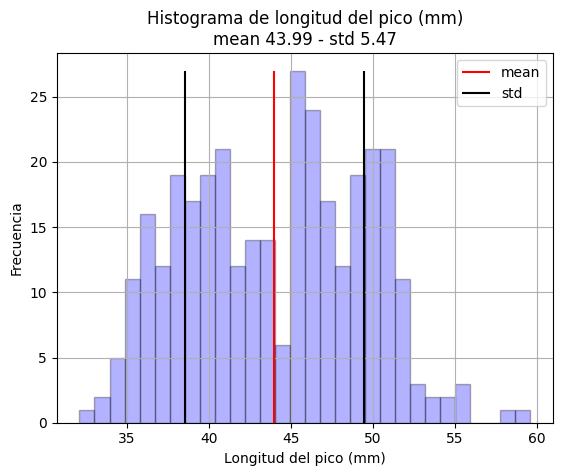

In [ ]:
# 4.

df.hist(column="longitud_pico (mm)",bins=30,alpha=0.3, color="blue", edgecolor="black")
plt.vlines(df["longitud_pico (mm)"].mean(), ymin=0, ymax=27, color="red", label="mean")
plt.vlines(df["longitud_pico (mm)"].mean() + df["longitud_pico (mm)"].std(), ymin=0, ymax=27, color="black", label="std")
plt.vlines(df["longitud_pico (mm)"].mean() - df["longitud_pico (mm)"].std(), ymin=0, ymax=27, color="black")


plt.title(f"Histograma de longitud del pico (mm)\nmean {df['longitud_pico (mm)'].mean():.2f} - std {df['longitud_pico (mm)'].std():.2f}")
plt.xlabel("Longitud del pico (mm)")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

Conteos totales por especie
especie
Adelie       146
Chinstrap     68
Gentoo       119
dtype: int64

Conteos totales por isla
isla
Biscoe       163
Dream        123
Torgersen     47
dtype: int64


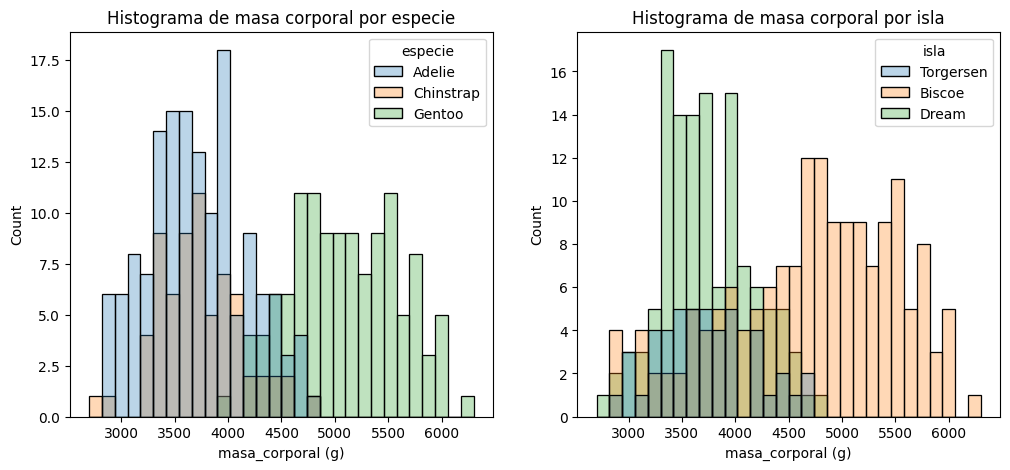

In [86]:
# Conteos totales por especie y por isla

conteos_por_especie = df.groupby("especie").size()
conteos_por_isla = df.groupby("isla").size()
print("Conteos totales por especie")
print(conteos_por_especie)

print("\nConteos totales por isla")
print(conteos_por_isla)


fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.histplot(data=df, x="masa_corporal (g)", hue="especie", bins=30, alpha=0.3, edgecolor="black",ax=axes[0])
axes[0].set_title("Histograma de masa corporal por especie")

sns.histplot(data=df, x="masa_corporal (g)", hue="isla", bins=30, alpha=0.3, edgecolor="black",ax=axes[1])
axes[1].set_title("Histograma de masa corporal por isla")

plt.show()


5. ¿Cuáles son las islas y especies presentes en el conjunto de datos? ¿Con qué frecuencia aparecen?

La respuesta a estapregunta se encuentra en el resultado de la linea anterior, ahi se visualizan las especies, islas y sus conteos